In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv('./dataset/data.csv')
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
504,915186,B,9.268,12.87,61.49,248.7,0.16340,0.22390,0.09730,0.05252,...,16.38,69.05,300.2,0.19020,0.34410,0.20990,0.10250,0.3038,0.12520,NaN
508,915452,B,16.300,15.70,104.70,819.8,0.09427,0.06712,0.05526,0.04563,...,17.76,109.80,928.2,0.13540,0.13610,0.19470,0.13570,0.2300,0.07230,NaN
319,894335,B,12.430,17.00,78.60,477.3,0.07557,0.03454,0.01342,0.01699,...,20.21,81.76,515.9,0.08409,0.04712,0.02237,0.02832,0.1901,0.05932,NaN
227,88147102,B,15.000,15.51,97.45,684.5,0.08371,0.10960,0.06505,0.03780,...,19.31,114.20,808.2,0.11360,0.36270,0.34020,0.13790,0.2954,0.08362,NaN
270,8910721,B,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,...,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120,NaN
6,844359,M,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.14420,0.25760,0.37840,0.19320,0.3063,0.08368,NaN
222,8812844,B,10.180,17.53,65.12,313.1,0.10610,0.08502,0.01768,0.01915,...,22.84,71.94,375.6,0.14060,0.14400,0.06572,0.05575,0.3055,0.08797,NaN
189,874839,B,12.300,15.90,78.83,463.7,0.08080,0.07253,0.03844,0.01654,...,19.59,86.65,546.7,0.10960,0.16500,0.14230,0.04815,0.2482,0.06306,NaN
326,89524,B,14.110,12.88,90.03,616.5,0.09309,0.05306,0.01765,0.02733,...,18.00,98.40,749.9,0.12810,0.11090,0.05307,0.05890,0.2100,0.07083,NaN
146,869691,M,11.800,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.07415,...,26.38,91.93,591.7,0.13850,0.40920,0.45040,0.18650,0.5774,0.10300,NaN


In [3]:
df = df.drop(columns=['Unnamed: 32', 'id'])

In [4]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [5]:
pd.set_option('display.max_columns', len(df.columns))

In [6]:
df.sample(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
71,B,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,0.5262,0.8522,3.168,25.44,0.017210,0.093680,0.05671,0.017660,0.02541,0.021930,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
139,B,11.280,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,0.1771,0.06072,0.3384,1.3430,1.851,26.33,0.011270,0.034980,0.02187,0.019650,0.01580,0.003442,11.920,15.77,76.53,434.0,0.13670,0.18220,0.08669,0.08611,0.2102,0.06784
191,B,12.770,21.41,82.02,507.4,0.08749,0.06601,0.03112,0.02864,0.1694,0.06287,0.7311,1.7480,5.118,53.65,0.004571,0.017900,0.02176,0.017570,0.03373,0.005875,13.750,23.50,89.04,579.5,0.09388,0.08978,0.05186,0.04773,0.2179,0.06871
192,B,9.720,18.22,60.73,288.1,0.06950,0.02344,0.00000,0.00000,0.1653,0.06447,0.3539,4.8850,2.230,21.69,0.001713,0.006736,0.00000,0.000000,0.03799,0.001688,9.968,20.83,62.25,303.8,0.07117,0.02729,0.00000,0.00000,0.1909,0.06559
20,B,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,0.1852,0.7477,1.383,14.67,0.004097,0.018980,0.01698,0.006490,0.01678,0.002425,14.500,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183
250,M,20.940,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,1.0040,0.8208,6.372,137.90,0.005283,0.039080,0.09518,0.018640,0.02401,0.005002,25.580,27.00,165.30,2010.0,0.12110,0.31720,0.69910,0.21050,0.3126,0.07849
415,B,11.890,21.17,76.39,433.8,0.09773,0.08120,0.02555,0.02179,0.2019,0.06290,0.2747,1.2030,1.930,19.53,0.009895,0.030530,0.01630,0.009276,0.02258,0.002272,13.050,27.21,85.09,522.9,0.14260,0.21870,0.11640,0.08263,0.3075,0.07351
459,B,9.755,28.20,61.68,290.9,0.07984,0.04626,0.01541,0.01043,0.1621,0.05952,0.1781,1.6870,1.243,11.28,0.006588,0.012700,0.01450,0.006104,0.01574,0.002268,10.670,36.92,68.03,349.9,0.11100,0.11090,0.07190,0.04866,0.2321,0.07211
31,M,11.840,18.70,77.93,440.6,0.11090,0.15160,0.12180,0.05182,0.2301,0.07799,0.4825,1.0300,3.475,41.00,0.005551,0.034140,0.04205,0.010440,0.02273,0.005667,16.820,28.12,119.40,888.7,0.16370,0.57750,0.69560,0.15460,0.4761,0.14020
509,M,15.460,23.95,103.80,731.3,0.11830,0.18700,0.20300,0.08520,0.1807,0.07083,0.3331,1.9610,2.937,32.52,0.009538,0.049400,0.06019,0.020410,0.02105,0.006000,17.110,36.33,117.70,909.4,0.17320,0.49670,0.59110,0.21630,0.3013,0.10670


In [7]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [8]:
df.shape

(569, 31)

In [9]:
with open('./dataset/wdbc.names', 'r') as files:
    for file in files:
        print(file.strip())

1. Title: Wisconsin Diagnostic Breast Cancer (WDBC)

2. Source Information

a) Creators:

Dr. William H. Wolberg, General Surgery Dept., University of
Wisconsin,  Clinical Sciences Center, Madison, WI 53792
wolberg@eagle.surgery.wisc.edu

W. Nick Street, Computer Sciences Dept., University of
Wisconsin, 1210 West Dayton St., Madison, WI 53706
street@cs.wisc.edu  608-262-6619

Olvi L. Mangasarian, Computer Sciences Dept., University of
Wisconsin, 1210 West Dayton St., Madison, WI 53706
olvi@cs.wisc.edu

b) Donor: Nick Street

c) Date: November 1995

3. Past Usage:

first usage:

W.N. Street, W.H. Wolberg and O.L. Mangasarian
Nuclear feature extraction for breast tumor diagnosis.
IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science
and Technology, volume 1905, pages 861-870, San Jose, CA, 1993.

OR literature:

O.L. Mangasarian, W.N. Street and W.H. Wolberg.
Breast cancer diagnosis and prognosis via linear programming.
Operations Research, 43(4), pages 570-577, July-Augu

In [10]:
numerik_df = df[df.describe().columns]
kategori_df = df.drop(columns=numerik_df.columns)

display(numerik_df.sample(10))
display(kategori_df.sample(10))

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.104400,0.056690,0.1895,0.06870,0.2366,1.4280,1.822,16.97,0.008064,0.017640,0.025950,0.010370,0.01357,0.003040,12.84,35.34,87.22,514.0,0.19090,0.26980,0.40230,0.14240,0.2964,0.09606
264,17.19,22.07,111.60,928.3,0.09726,0.08995,0.090610,0.065270,0.1867,0.05580,0.4203,0.7383,2.819,45.42,0.004493,0.012060,0.020480,0.009875,0.01144,0.001575,21.58,29.33,140.50,1436.0,0.15580,0.25670,0.38890,0.19840,0.3216,0.07570
411,11.04,16.83,70.92,373.2,0.10770,0.07804,0.030460,0.024800,0.1714,0.06340,0.1967,1.3870,1.342,13.54,0.005158,0.009355,0.010560,0.007483,0.01718,0.002198,12.41,26.44,79.93,471.4,0.13690,0.14820,0.10670,0.07431,0.2998,0.07881
309,13.05,13.84,82.71,530.6,0.08352,0.03735,0.004559,0.008829,0.1453,0.05518,0.3975,0.8285,2.567,33.01,0.004148,0.004711,0.002831,0.004821,0.01422,0.002273,14.73,17.40,93.96,672.4,0.10160,0.05847,0.01824,0.03532,0.2107,0.06580
472,14.92,14.93,96.45,686.9,0.08098,0.08549,0.055390,0.032210,0.1687,0.05669,0.2446,0.4334,1.826,23.31,0.003271,0.017700,0.023100,0.008399,0.01148,0.002379,17.18,18.22,112.00,906.6,0.10650,0.27910,0.31510,0.11470,0.2688,0.08273
482,13.47,14.06,87.32,546.3,0.10710,0.11550,0.057860,0.052660,0.1779,0.06639,0.1588,0.5733,1.102,12.84,0.004450,0.014520,0.013340,0.008791,0.01698,0.002787,14.83,18.32,94.94,660.2,0.13930,0.24990,0.18480,0.13350,0.3227,0.09326
289,11.37,18.89,72.17,396.0,0.08713,0.05008,0.023990,0.021730,0.2013,0.05955,0.2656,1.9740,1.954,17.49,0.006538,0.013950,0.013760,0.009924,0.03416,0.002928,12.36,26.14,79.29,459.3,0.11180,0.09708,0.07529,0.06203,0.3267,0.06994
305,11.60,24.49,74.23,417.2,0.07474,0.05688,0.019740,0.013130,0.1935,0.05878,0.2512,1.7860,1.961,18.21,0.006122,0.023370,0.015960,0.006998,0.03194,0.002211,12.44,31.62,81.39,476.5,0.09545,0.13610,0.07239,0.04815,0.3244,0.06745
509,15.46,23.95,103.80,731.3,0.11830,0.18700,0.203000,0.085200,0.1807,0.07083,0.3331,1.9610,2.937,32.52,0.009538,0.049400,0.060190,0.020410,0.02105,0.006000,17.11,36.33,117.70,909.4,0.17320,0.49670,0.59110,0.21630,0.3013,0.10670
425,10.03,21.28,63.19,307.3,0.08117,0.03912,0.002470,0.005159,0.1630,0.06439,0.1851,1.3410,1.184,11.60,0.005724,0.005697,0.002074,0.003527,0.01445,0.002411,11.11,28.94,69.92,376.3,0.11260,0.07094,0.01235,0.02579,0.2349,0.08061


,diagnosis
568,B
432,M
310,B
558,B
368,M
412,B
4,M
328,M
228,B
497,B


In [128]:
class PlotFeatures:
    def __init__(self, df, target_cols, par=1, combinations=True):
        self.par = par
        self.data = df
        self.combinations = combinations
        self.target_cols = target_cols

    def get_layout_axes(self):
        from itertools import combinations_with_replacement 
        get_values_comb_1 = combinations_with_replacement(self.target_cols, 2)
        get_values_comb_2 = combinations_with_replacement(self.target_cols, 2)  
        
        map = {}
        arr = []

        if self.par > 0:
            if self.combinations:
                k = int(len(list(get_values_comb_1)) / self.par)
            else:
                k = int(len(self.target_cols) / self.par)

            for i in range(1, k):
                for j in range(i, k - i):
                    map[i*j] = (i, j)

            for i in range(1, self.par):
                arr.append(k*i)
        else:
             raise Exception('Nilai par anda masukkan bernilai 0 atau negatif!!!')

        self.comb = list(get_values_comb_2)
        self.layout = map.get(k) or map[min(map.keys(), key=lambda key: abs(key-k))]
        self.indices = arr

    def plot_features(self, target='all', kind='scatter', figsize=(20, 80), target_idx=(0,1), **kwargs):
        params_style = {
            'data': None,
            'x': None,
            'y': None,
            'hue': None,
            'weights': None,
            'stat': 'count',
            'bins': 'auto',
            'binwidth': None,
            'binrange': None,
            'discrete': None,
            'cumulative': False,
            'common_bins': True,
            'common_norm': True,
            'multiple': 'layer',
            'element': 'bars',
            'fill': True,
            'shrink': 1,
            'kde': False,
            'kde_kws': None,
            'line_kws': None,
            'thresh': 0,
            'pthresh': None,
            'pmax': None,
            'cbar': False,
            'cbar_ax': None,
            'cbar_kws': None,
            'palette': None,
            'hue_order': None,
            'hue_norm': None,
            'color': None,
            'log_scale': None,
            'legend': True,
            'ax': None,
            'size': None,
            'style': None,
            'units': None,
            'row': None,
            'col': None,
            'col_wrap': None,
            'row_order': None,
            'col_order': None,
            'sizes': None,
            'size_order': None,
            'size_norm': None,
            'markers': None,
            'dashes': True,
            'style_order': None,
            'kind': 'scatter',
            'height': 5,
            'aspect': 1,
            'facet_kws': None,
            'estimator': 'mean',
            'errorbar': ('ci', 95),
            'n_boot,': 1000,
            'seed': None,
            'orient': None,
            'sort': True,
            'err_style': 'band',
            'err_kws': None,
            'ci': 95,
            'order_cat': None,
            'order_int': None,
            'saturation': 0.75,
            'width': 0.8,
            'dodge': True,
            'fliersize': 5,
            'linewidth': None,
            'whis': 1.5,
            'ata': None,
            'bw': 'scott',
            'cut': 2,
            'scale': 'area',
            'scale_hue': True,
            'gridsize': 100,
            'inner': 'box',
            'split': False,
            'x_estimator': None,
            'x_bins': None,
            'x_ci': 'ci',
            'scatter': True,
            'fit_reg': True,
            'n_boot': 1000,
            'logistic': False,
            'lowess': False,
            'robust': False,
            'logx': False,
            'x_partial': None,
            'y_partial': None,
            'truncate': True,
            'dropna': True,
            'x_jitter': None,
            'y_jitter': None,
            'label': None,
            'marker': 'o',
            'scatter_kws': None,
        }

        for i in params_style:
            if i in kwargs:
                params_style[i] = kwargs[i]

        plt.figure(figsize=figsize)

        if kind == 'scatter':

            if self.par > 1:
                lower = self.indices[0]
                upper = self.indices[-1]

            if self.par > 2:
                middle_1 = self.indices[target_idx[0]]
                middle_2 = self.indices[target_idx[1]]
            
            for idx, col in \
            enumerate(self.comb[upper:]) if target=='upper' else \
            enumerate(self.comb[middle_1:middle_2]) if target=='middle' else \
            enumerate(self.comb[:lower]) if target=='lower' else enumerate(self.comb):

                plt.subplot(max(self.layout)+1,min(self.layout),idx+1)
                sns.scatterplot(data=self.data, x=col[0], y=col[1], hue=params_style['hue'], size=params_style['size'], style=params_style['style'], palette=params_style['palette'], hue_order=params_style['hue_order'], hue_norm=params_style['hue_norm'], sizes=params_style['sizes'], size_order=params_style['size_order'], size_norm=params_style['size_norm'], markers=params_style['markers'], style_order=params_style['style_order'], legend=params_style['legend'], ax=params_style['ax'])
            
        elif kind == 'hist':
            for idx, col in enumerate(np.unique(self.comb)):
                plt.subplot(max(self.layout) + 1, min(self.layout), idx+1)
                sns.histplot(data=self.data, x=col, y=params_style['y'], hue=params_style['hue'], weights=params_style['weights'], stat=params_style['stat'], bins=params_style['bins'], binwidth=params_style['binwidth'], binrange=params_style['binrange'], discrete=params_style['discrete'], cumulative=params_style['cumulative'], common_bins=params_style['common_bins'], common_norm=params_style['common_norm'], multiple=params_style['multiple'], element=params_style['element'], fill=params_style['fill'], shrink=params_style['shrink'], kde=params_style['kde'], kde_kws=params_style['kde_kws'], line_kws=params_style['line_kws'], thresh=params_style['thresh'], pthresh=params_style['pthresh'], pmax=params_style['pmax'], cbar=params_style['cbar'], cbar_ax=params_style['cbar_ax'], cbar_kws=params_style['cbar_kws'], palette=params_style['palette'], hue_order=params_style['hue_order'], hue_norm=params_style['hue_norm'], color=params_style['color'], log_scale=params_style['log_scale'], legend=params_style['legend'], ax=params_style['ax'])

        elif kind == 'regplot':
                if self.par > 1:
                    lower = self.indices[0]
                    upper = self.indices[-1]

                if self.par > 2:
                    middle_1 = self.indices[target_idx[0]]
                    middle_2 = self.indices[target_idx[1]]

                for idx, col in \
                    enumerate(self.comb[upper:]) if target=='upper' else \
                    enumerate(self.comb[middle_1:middle_2]) if target=='middle' else \
                    enumerate(self.comb[:lower]) if target=='lower' else enumerate(self.comb):
                    
                    plt.subplot(max(self.layout) + 5, min(self.layout), idx+1)
                    sns.regplot(data=self.data, x=col[0], y=col[1], x_estimator=params_style['x_estimator'], x_bins=params_style['x_bins'], x_ci=params_style['x_ci'], scatter=params_style['scatter'], fit_reg=params_style['fit_reg'], ci=params_style['ci'], n_boot=params_style['n_boot'], units=params_style['units'], seed=params_style['seed'], order=params_style['order_int'], logistic=params_style['logistic'], lowess=params_style['lowess'], robust=params_style['robust'], logx=params_style['logx'], x_partial=params_style['x_partial'], y_partial=params_style['y_partial'], truncate=params_style['truncate'], dropna=params_style['dropna'], x_jitter=params_style['x_jitter'], y_jitter=params_style['y_jitter'], label=params_style['label'], color=params_style['color'], marker=params_style['marker'], scatter_kws=params_style['scatter_kws'], line_kws=params_style['line_kws'], ax=params_style['ax'])

        elif kind == 'boxplot':
            for idx, col in enumerate(np.unique(self.comb)):
                plt.subplot(max(self.layout) + 1, min(self.layout), idx+1)
                sns.boxplot(data=self.data, x=col, y=params_style['y'], hue=params_style['hue'], order=params_style['order_cat'], hue_order=params_style['hue_order'], orient=params_style['orient'], color=params_style['color'], palette=params_style['palette'], saturation=params_style['saturation'], width=params_style['width'], dodge=params_style['dodge'], fliersize=params_style['fliersize'], linewidth=params_style['linewidth'], whis=params_style['whis'], ax=params_style['ax'])

        elif kind == 'violinplot':
            for idx, col in enumerate(np.unique(self.comb)):
                plt.subplot(max(self.layout) + 1, min(self.layout), idx+1)
                sns.violinplot(data=self.data, x=col, y=params_style['y'], hue=params_style['hue'], order=params_style['order_cat'], hue_order=params_style['hue_order'], bw=params_style['bw'], cut=params_style['cut'], scale=params_style['scale'], scale_hue=params_style['scale_hue'], gridsize=params_style['gridsize'], width=params_style['width'], inner=params_style['inner'], split=params_style['split'], dodge=params_style['dodge'], orient=params_style['orient'], linewidth=params_style['linewidth'], color=params_style['color'], palette=params_style['palette'], saturation=params_style['saturation'], ax=params_style['ax'])

        plt.tight_layout()
        plt.show()

In [102]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


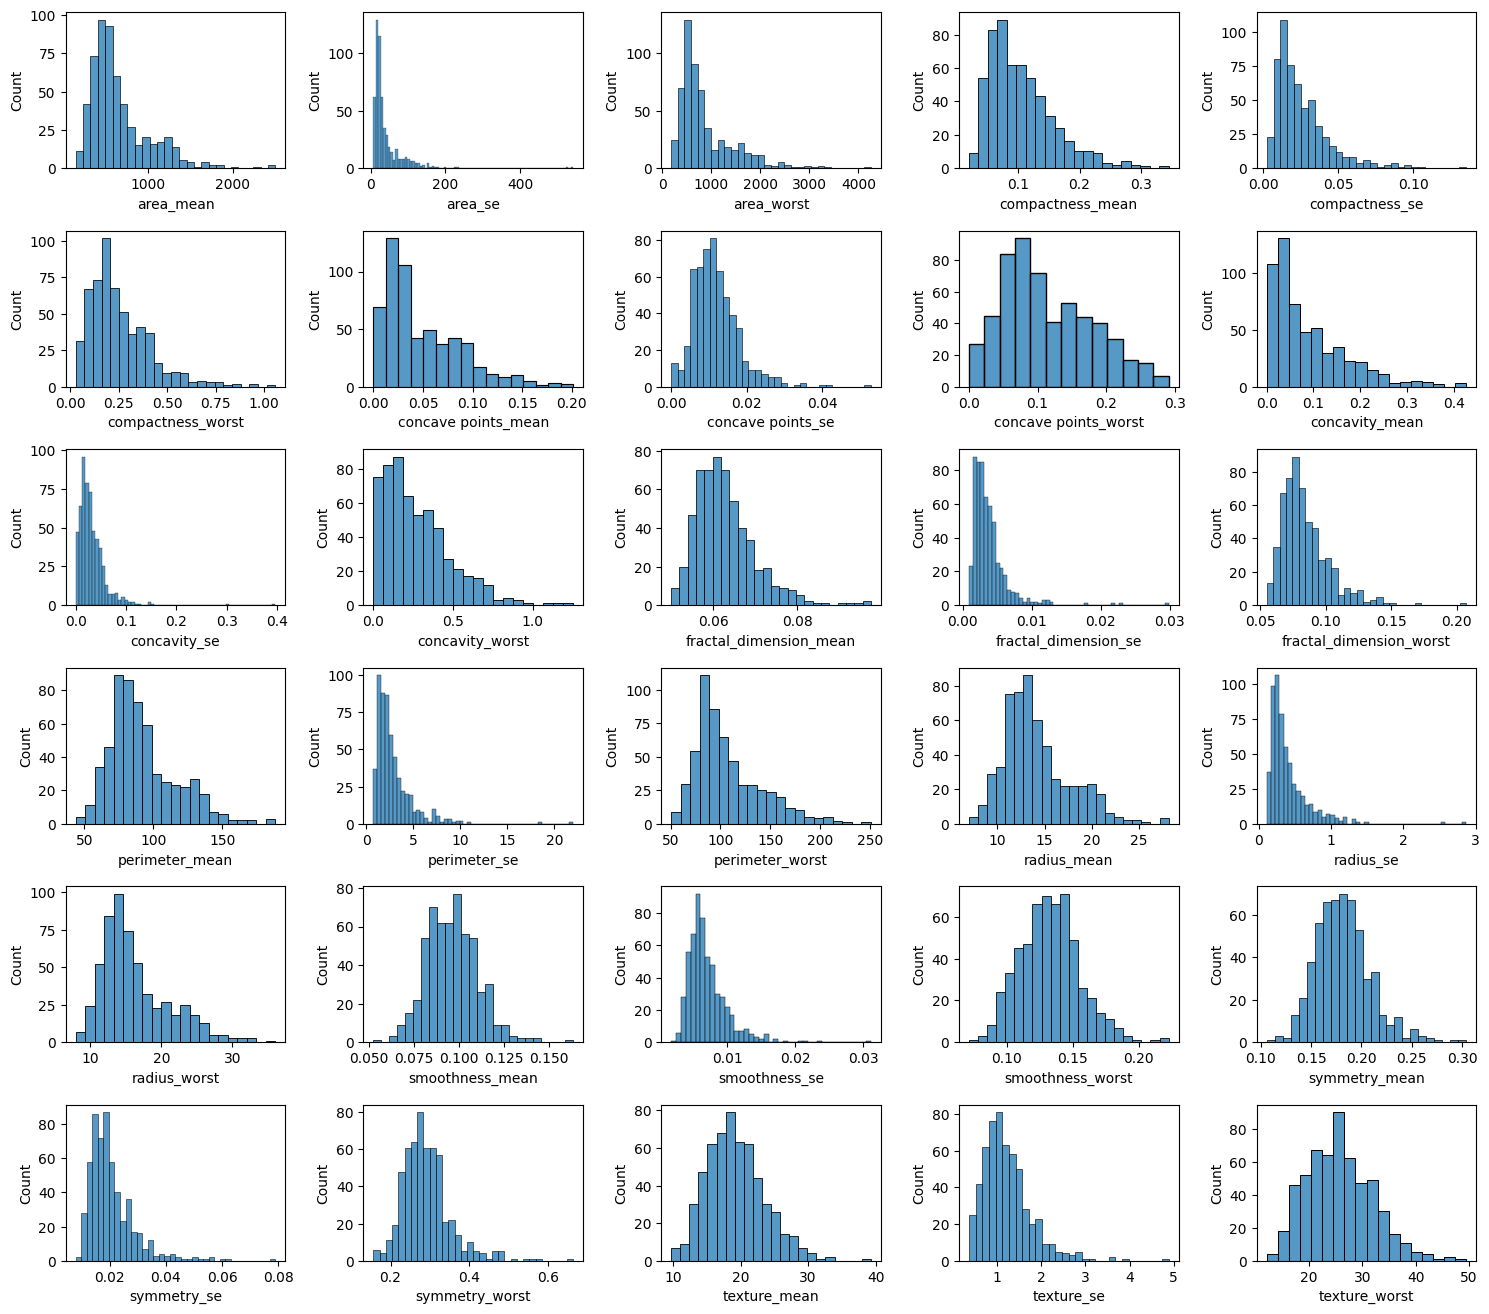

In [129]:
plot_hist = PlotFeatures(df, numerik_df.columns, combinations=False)
plot_hist.get_layout_axes()

plot_hist.plot_features(kind='hist', figsize=(15,15))

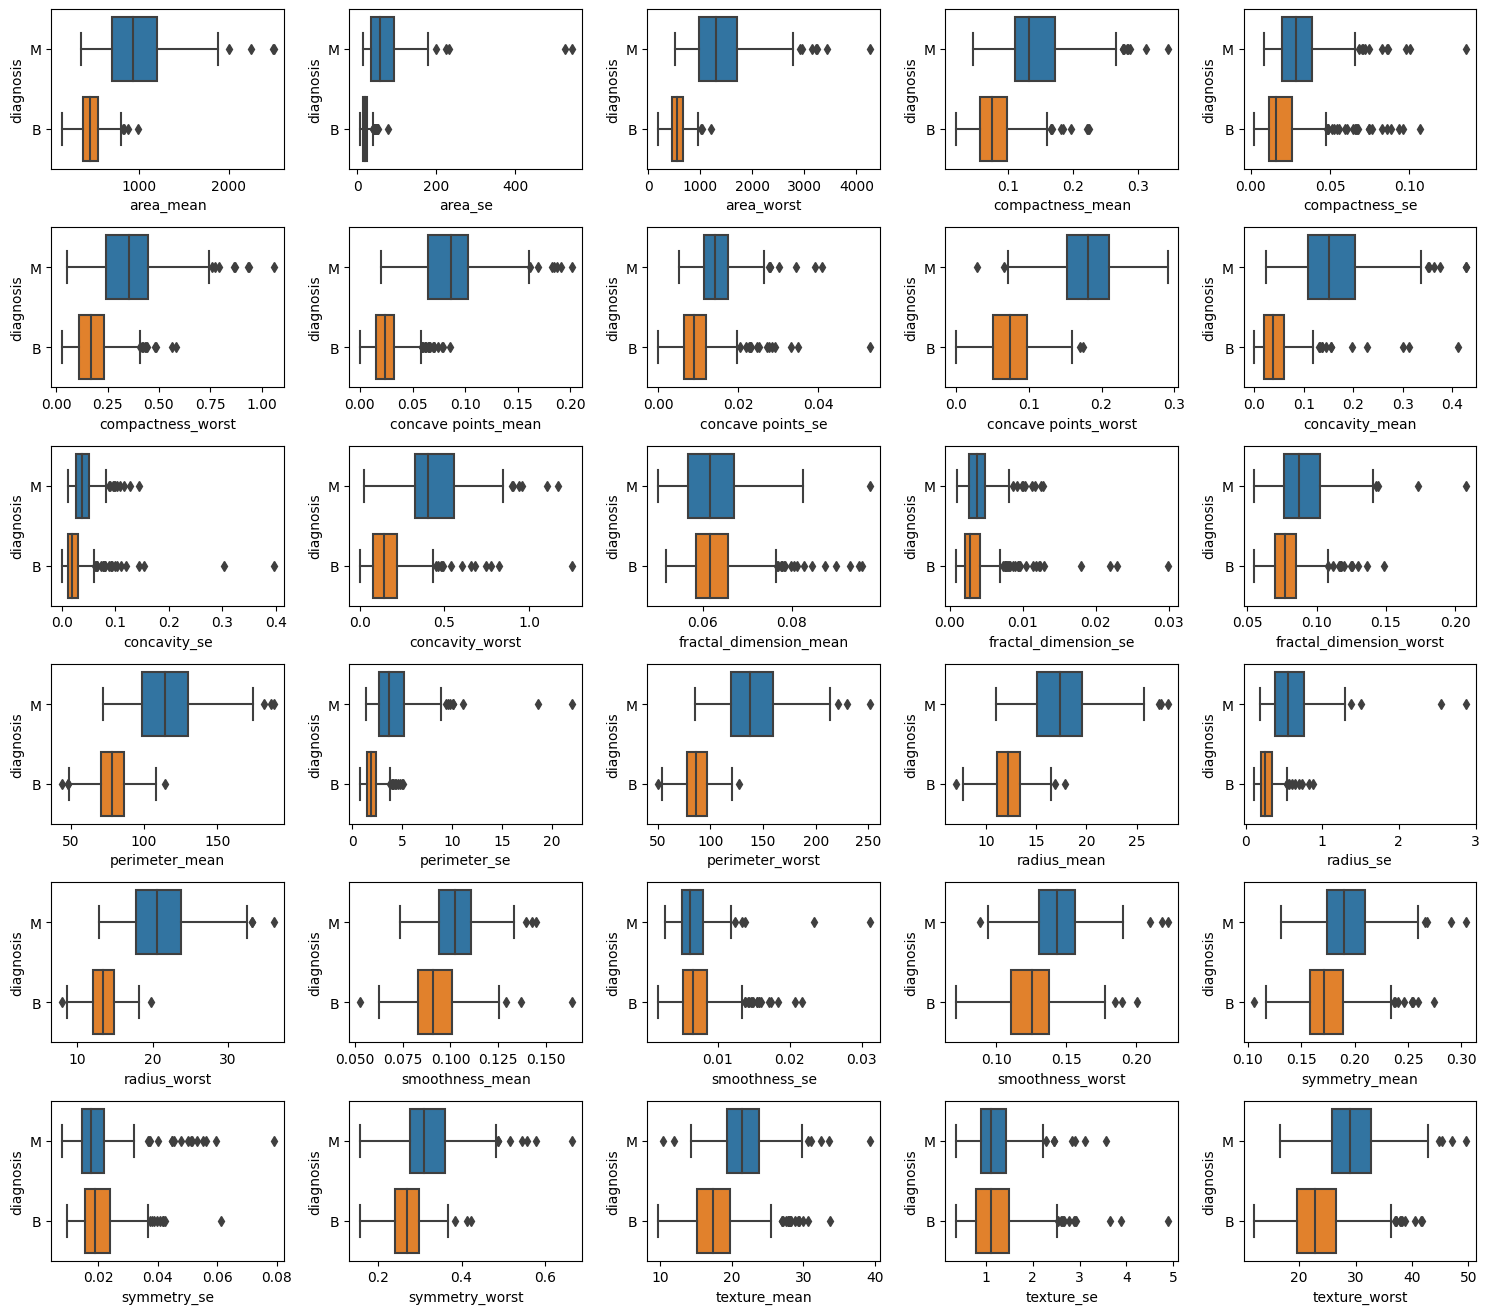

In [138]:
plot_hist = PlotFeatures(df, numerik_df.columns, combinations=False)
plot_hist.get_layout_axes()

plot_hist.plot_features(kind='boxplot', figsize=(15, 15), y='diagnosis')

In [139]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


* area_se
* area_mean
* perimeter_se
* concavity_se
* radius_se
* smoothness_se
* radius_worst
* perimeter_worst
* area_worst

In [140]:
class Clean_Data:
  def __init__(self, data, target_columns):
    self.target_columns = target_columns
    self.data = data

  def detect_outlier(self):
    q1, q3, iqr, lower_limit, upper_limit = {}, {}, {}, {}, {}
    select_data = self.data[self.target_columns].quantile([.25, .75])

    for key, val in select_data.to_dict().items():  
      q1[key] = val[0.25]
      q3[key] = val[0.75]
      iqr[key] = q3[key] - q1[key]
      lower_limit[key], upper_limit[key] = q1[key] - 1.5*iqr[key], q3[key] + 1.5*iqr[key]

    self.lower_limit = lower_limit
    self.upper_limit = upper_limit
    self.q1 = q1
    self.q3 = q3
    self.iqr = iqr

  def remove_outlier(self):
    new_df = self.data.copy(deep=True)
    for col in self.target_columns:
      new_df = new_df[new_df[col].between(self.lower_limit[col], self.upper_limit[col])]
    
    return new_df

In [141]:
target_cols_outlier = ['area_se','area_mean','perimeter_se','concavity_se','radius_se','smoothness_se','radius_worst','perimeter_worst','area_worst']
df[target_cols_outlier].quantile([0.97, 0.98, 0.99])

,area_se,area_mean,perimeter_se,concavity_se,radius_se,smoothness_se,radius_worst,perimeter_worst,area_worst
0.97,134.728,1418.52,7.73060,0.092626,1.05752,0.013848,27.2964,184.584,2231.80
0.98,154.936,1625.36,8.62740,0.101584,1.17020,0.015280,28.3244,195.576,2491.08
0.99,177.684,1786.60,9.69004,0.122292,1.29132,0.017258,30.7628,208.304,2918.16


In [155]:
clean_df = Clean_Data(df, target_cols_outlier)
clean_df.detect_outlier()
bc_df_fixed  = clean_df.remove_outlier()

print(clean_df.lower_limit)
print()
print(clean_df.upper_limit)

{'area_se': -23.15999999999999, 'area_mean': -123.30000000000001, 'perimeter_se': -1.0205, 'concavity_se': -0.025349999999999998, 'radius_se': -0.13735000000000003, 'smoothness_se': 0.0007034999999999993, 'radius_worst': 4.340000000000002, 'perimeter_worst': 22.17499999999999, 'area_worst': -337.7500000000001}

{'area_se': 86.19999999999999, 'area_mean': 1326.3000000000002, 'perimeter_se': 5.9835, 'concavity_se': 0.08249, 'radius_se': 0.84865, 'smoothness_se': 0.012611500000000001, 'radius_worst': 27.459999999999997, 'perimeter_worst': 187.335, 'area_worst': 1937.0500000000002}


In [160]:
bc_df_fixed.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000
mean,13.404533,18.959583,86.794123,573.782895,0.094545,0.092838,0.068876,0.038994,0.177054,0.062058,0.318445,1.155750,2.249434,27.522654,0.006486,0.021545,0.025913,0.010287,0.019416,0.003280,15.188542,25.388136,99.604890,738.852851,0.130595,0.234704,0.239657,0.102013,0.287305,0.082515
std,2.545558,4.291896,17.348455,227.377356,0.013866,0.043396,0.058482,0.028455,0.024647,0.006133,0.132595,0.529417,0.942509,15.882702,0.002056,0.012881,0.016979,0.004525,0.006679,0.001684,3.320942,6.137500,22.930797,336.853027,0.023213,0.148104,0.186215,0.056586,0.058992,0.017722
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.114400,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.009539,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210
25%,11.707500,15.852500,75.022500,420.300000,0.084572,0.060475,0.026418,0.018927,0.160100,0.057655,0.220300,0.808725,1.526500,16.970000,0.005019,0.012037,0.013865,0.007024,0.014895,0.002102,13.025000,20.687500,84.057500,515.675000,0.113900,0.136325,0.104875,0.062172,0.248150,0.070517
50%,13.020000,18.505000,84.115000,520.100000,0.093925,0.082640,0.048765,0.029240,0.176000,0.061180,0.286650,1.046500,2.070500,22.335000,0.006059,0.017935,0.021805,0.009923,0.018175,0.002847,14.495000,25.090000,95.120000,639.200000,0.129700,0.196400,0.190250,0.087895,0.278950,0.078700
75%,14.765000,21.530000,96.145000,669.375000,0.103225,0.114825,0.098110,0.055990,0.192600,0.065340,0.396425,1.381250,2.765000,33.157500,0.007595,0.028748,0.034865,0.012930,0.021955,0.003951,16.825000,29.212500,113.100000,862.025000,0.143100,0.296175,0.334525,0.140875,0.315150,0.090133
max,20.590000,39.280000,137.800000,1320.000000,0.163400,0.283900,0.318900,0.146900,0.274300,0.097440,0.747400,4.885000,5.801000,83.500000,0.012430,0.074580,0.081580,0.034410,0.059630,0.011780,24.560000,49.540000,166.400000,1872.000000,0.222600,1.058000,1.170000,0.270100,0.663800,0.207500


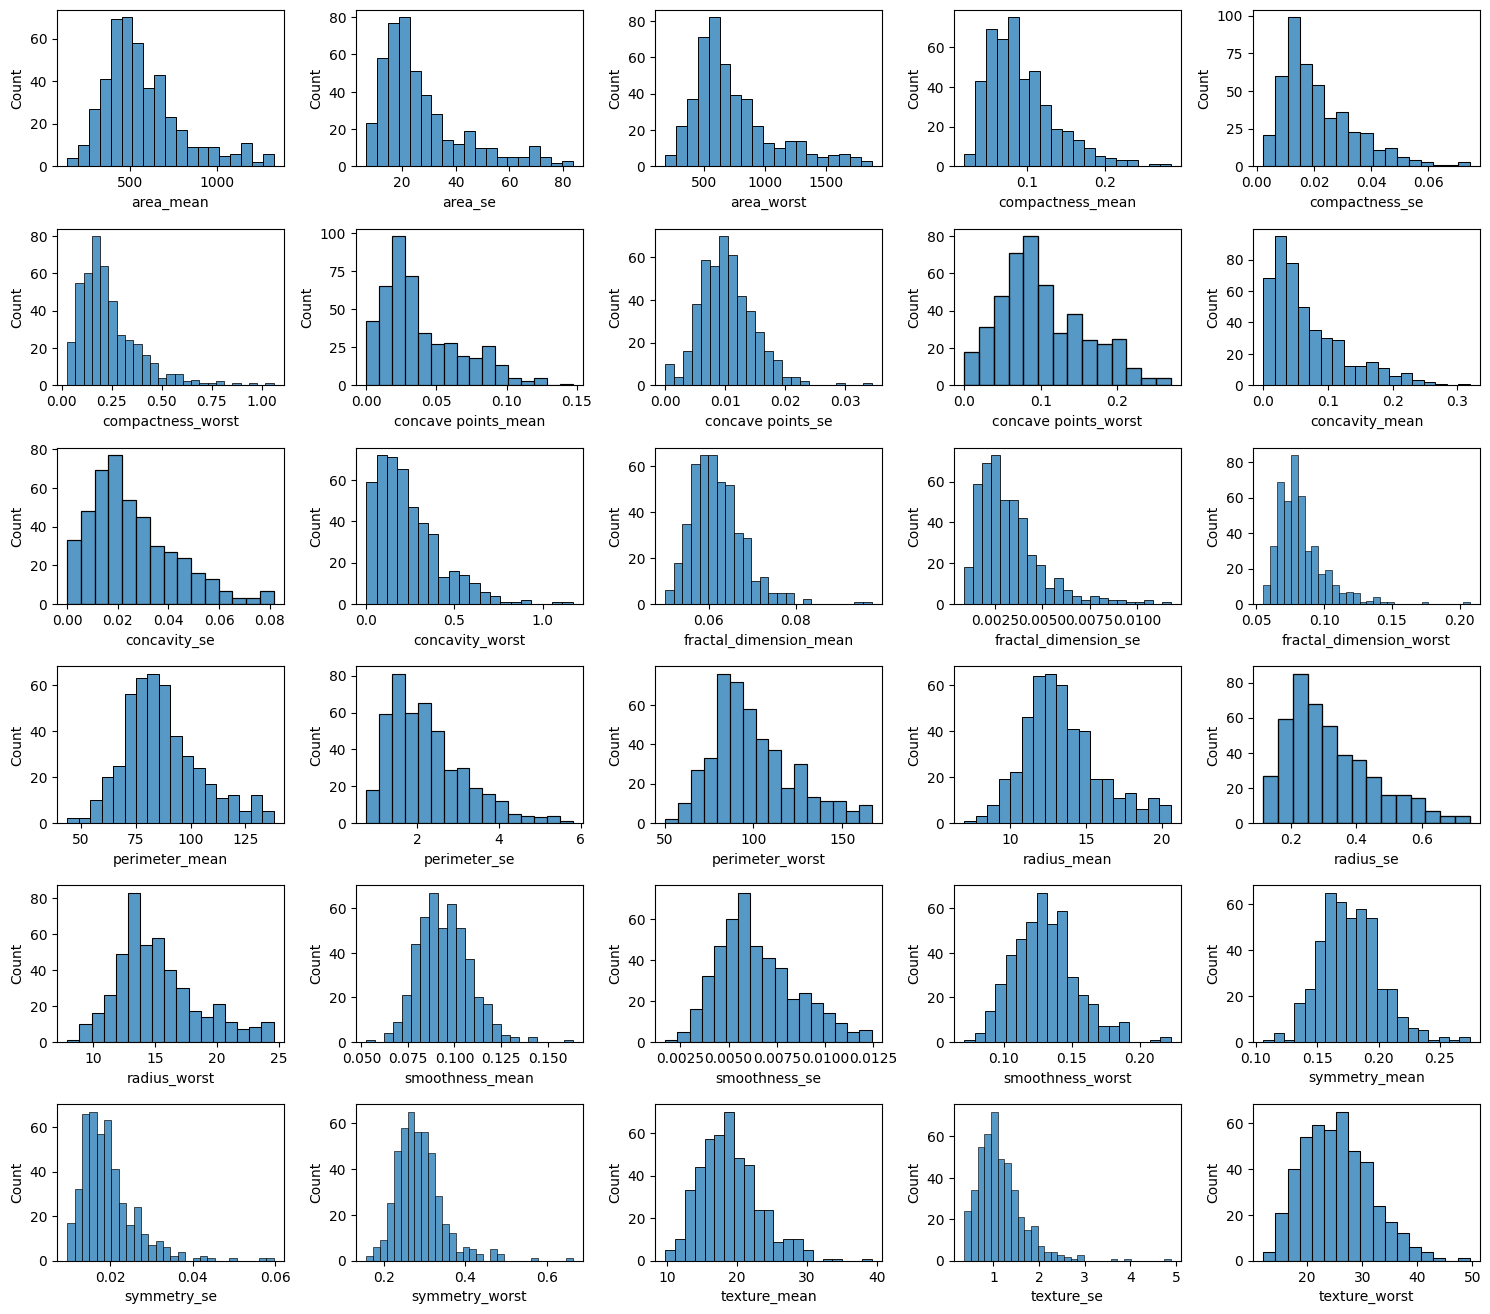

In [159]:
plot_hist = PlotFeatures(bc_df_fixed, numerik_df.columns, combinations=False)
plot_hist.get_layout_axes()

plot_hist.plot_features(kind='hist', figsize=(15,15))

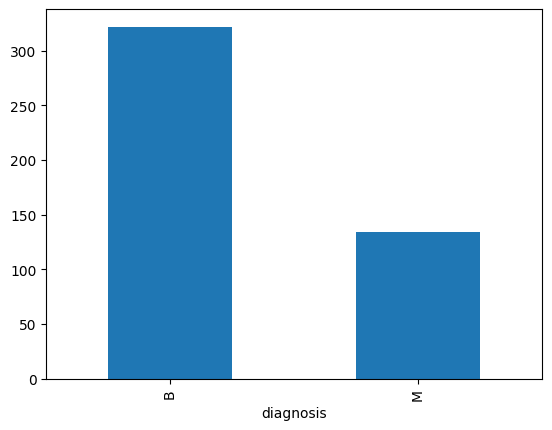

In [163]:
by_diagnosis = bc_df_fixed.groupby(by='diagnosis')
by_diagnosis.size().plot(kind='bar')
plt.show()

In [164]:
by_diagnosis[bc_df_fixed.columns].mean().T.sort_values(by=['B', 'M'], ascending=False)

diagnosis,B,M
area_worst,575.329193,1131.797761
area_mean,475.703416,809.466418
perimeter_worst,88.298012,126.775149
perimeter_mean,79.165062,105.126642
texture_worst,23.607795,29.666269
area_se,20.669317,43.991119
texture_mean,17.907919,21.486716
radius_worst,13.585885,19.039701
radius_mean,12.326575,15.994851
perimeter_se,1.919381,3.042545


### BAKAL GUA LANJUT

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

X_sm_1, y_sm_1 = smote.fit_resample(X_1_transformed, y_1_transformed)

In [10]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif

x_train = df.drop(['diagnosis'], axis='columns')
y_train = df['diagnosis']

f, p = f_classif(x_train, y_train)
mi = mutual_info_classif(x_train, y_train)

features_df = pd.DataFrame({
    'Features': x_train.columns,
    'F scores': f,
    'MI scores': mi
}).set_index('Features').sort_values(['MI scores', 'F scores'], ascending=False)

features_df.style.bar(subset=['F scores', 'MI scores'], color='grey')

,F scores,MI scores
Features,,
perimeter_worst,897.944219,0.476083
area_worst,661.600206,0.465042
radius_worst,860.781707,0.455562
concave points_worst,964.385393,0.439966
concave points_mean,861.676020,0.438028
perimeter_mean,697.235272,0.401129
concavity_mean,533.793126,0.374345
radius_mean,646.981021,0.368475
area_mean,573.060747,0.359993


In [11]:
features_target = list(features_df['MI scores'].nlargest(15).index)
features_target.append('diagnosis')
features_target

['perimeter_worst',
 'area_worst',
 'radius_worst',
 'concave points_worst',
 'concave points_mean',
 'perimeter_mean',
 'concavity_mean',
 'radius_mean',
 'area_mean',
 'area_se',
 'concavity_worst',
 'perimeter_se',
 'radius_se',
 'compactness_worst',
 'compactness_mean',
 'diagnosis']

In [16]:
def get_iqr_limit(df, target_cols):
    quantile_df = df[target_cols].quantile([.25, .75])
    iqr_dict = {}
    for col in quantile_df:
        iqr = quantile_df.loc[.75, col] - quantile_df.loc[.25, col]
        iqr_dict[col] = (quantile_df.loc[.25, col] - 1.5*iqr, quantile_df.loc[.75, col] + 1.5*iqr)
    return iqr_dict

iqr_dicts = get_iqr_limit(df, df.columns)
iqr_dicts

{'perimeter_worst': (22.17499999999999, 187.335),
 'area_worst': (-337.7500000000001, 1937.0500000000002),
 'radius_worst': (4.340000000000002, 27.459999999999997),
 'concave points_worst': (-0.07977499999999997, 0.30610499999999996),
 'concave points_mean': (-0.060224999999999994, 0.15453499999999998),
 'perimeter_mean': (31.775000000000013, 147.49499999999998),
 'concavity_mean': (-0.12215000000000001, 0.28241000000000005),
 'radius_mean': (5.579999999999999, 21.9),
 'area_mean': (-123.30000000000001, 1326.3000000000002),
 'area_se': (-23.15999999999999, 86.19999999999999),
 'concavity_worst': (-0.2881000000000001, 0.7855000000000001),
 'perimeter_se': (-1.0205, 5.9835),
 'radius_se': (-0.13735000000000003, 0.84865),
 'compactness_worst': (-0.14065000000000005, 0.6269500000000001),
 'compactness_mean': (-0.03329999999999997, 0.22861999999999996)}

In [17]:
print('max   | iqr(q3)')
print('_'.center(30, '_'))
for col, val in iqr_dicts.items():
    print(f'%-5d | {val[1]}' %(df[col].max()))

max   | iqr(q3)
______________________________
251   | 187.335
4254  | 1937.0500000000002
36    | 27.459999999999997
0     | 0.30610499999999996
0     | 0.15453499999999998
188   | 147.49499999999998
0     | 0.28241000000000005
28    | 21.9
2501  | 1326.3000000000002
542   | 86.19999999999999
1     | 0.7855000000000001
21    | 5.9835
2     | 0.84865
1     | 0.6269500000000001
0     | 0.22861999999999996


In [18]:
for col, val in iqr_dicts.items():
    display(df.loc[~df[col].between(val[0], val[1]), col])

23     188.0
82     211.7
108    206.8
180    220.8
212    188.5
236    206.0
265    214.0
272    195.9
339    202.4
352    229.3
368    199.5
369    195.0
461    251.2
503    211.5
521    205.7
Name: perimeter_worst, dtype: float64

0      2019.0
1      1956.0
18     2398.0
23     2615.0
24     2215.0
56     2145.0
82     2562.0
108    2360.0
122    2073.0
162    2232.0
164    2403.0
180    3216.0
181    2089.0
202    1986.0
212    2499.0
218    2009.0
219    2477.0
236    2944.0
250    2010.0
254    1972.0
265    3432.0
272    2384.0
300    2053.0
323    1938.0
339    2906.0
352    3234.0
368    3143.0
369    2227.0
373    1946.0
393    2081.0
449    2022.0
461    4254.0
503    2782.0
521    2642.0
564    2027.0
Name: area_worst, dtype: float64

23     29.17
82     30.00
108    28.40
164    28.01
180    33.12
212    28.11
219    27.90
236    31.01
265    32.49
272    28.19
339    30.67
352    33.13
368    30.75
369    27.66
461    36.04
503    30.79
521    29.92
Name: radius_worst, dtype: float64

Series([], Name: concave points_worst, dtype: float64)

78     0.1604
82     0.1845
108    0.1823
122    0.2012
180    0.1878
202    0.1620
212    0.1595
352    0.1913
393    0.1562
461    0.1689
Name: concave points_mean, dtype: float64

...

9      1.1050
68     1.2520
108    0.9608
152    0.8216
190    0.8488
202    0.7892
252    0.8489
379    0.8402
400    0.9034
430    0.9019
562    1.1700
567    0.9387
Name: concavity_worst, dtype: float64

0       8.589
12     11.070
25      7.276
38      8.077
42      8.830
77      6.311
78      8.649
82      7.382
108    10.050
122     9.807
138     8.419
161     6.971
168     7.337
210     7.029
212    21.980
218     6.487
236     7.247
250     6.372
256     7.158
258    10.120
262     6.146
265     7.749
272     8.867
300     7.237
302     7.804
335     6.076
339     6.462
352     7.222
366     7.128
368     7.733
369     7.561
417     9.424
460     6.051
461    18.650
503     9.635
521     7.050
563     8.758
564     7.673
Name: perimeter_se, dtype: float64

0      1.0950
12     0.9555
25     1.0460
27     0.8529
38     1.2140
42     0.9811
77     0.9806
78     0.9317
82     0.8973
108    1.2150
122    1.5090
138    1.2960
161    1.0000
168    1.0880
210    0.8601
212    2.8730
218    0.9553
236    1.0580
250    1.0040
258    1.2920
265    1.1720
272    1.1670
290    0.8811
300    1.1110
302    1.0720
339    1.0090
352    0.9948
366    0.9761
368    1.2070
369    1.0080
417    1.3700
460    0.9291
461    2.5470
468    0.9289
503    1.2910
521    0.9915
563    0.9622
564    1.1760
Name: radius_se, dtype: float64

0      0.6656
3      0.8663
9      1.0580
14     0.7725
15     0.6577
26     0.6643
33     0.6590
42     0.7444
72     0.7394
108    0.6997
181    0.7584
190    0.9327
379    0.9379
430    0.7090
562    0.7917
567    0.8681
Name: compactness_worst, dtype: float64

0      0.2776
3      0.2839
9      0.2396
12     0.2458
14     0.2293
78     0.3454
82     0.2665
108    0.2768
122    0.2867
181    0.2832
190    0.2413
258    0.3114
351    0.2364
352    0.2363
400    0.2576
567    0.2770
Name: compactness_mean, dtype: float64

In [19]:
new_df = df.copy(deep=True)

new_df = df[
    (df['perimeter_worst'].between(iqr_dicts['perimeter_worst'][0], iqr_dicts['perimeter_worst'][1])) &
    (df['area_worst'].between(iqr_dicts['area_worst'][0], iqr_dicts['area_worst'][1])) &
    (df['radius_worst'].between(iqr_dicts['radius_worst'][0], iqr_dicts['radius_worst'][1])) &
    (df['concave points_mean'].between(iqr_dicts['concave points_mean'][0], iqr_dicts['concave points_mean'][1])) &
    (df['concave points_worst'].between(iqr_dicts['concave points_worst'][0], iqr_dicts['concave points_worst'][1])) &
    (df['perimeter_mean'].between(iqr_dicts['perimeter_mean'][0], iqr_dicts['perimeter_mean'][1])) &
    (df['concavity_mean'].between(iqr_dicts['concavity_mean'][0], iqr_dicts['concavity_mean'][1])) &
    (df['radius_mean'].between(iqr_dicts['radius_mean'][0], iqr_dicts['radius_mean'][1])) &
    (df['area_mean'].between(iqr_dicts['area_mean'][0], iqr_dicts['area_mean'][1])) &
    (df['area_se'].between(iqr_dicts['area_se'][0], iqr_dicts['area_se'][1])) &
    (df['concavity_worst'].between(iqr_dicts['concavity_worst'][0], iqr_dicts['concavity_worst'][1])) &
    (df['perimeter_se'].between(iqr_dicts['perimeter_se'][0], iqr_dicts['perimeter_se'][1])) &
    (df['radius_se'].between(iqr_dicts['radius_se'][0], iqr_dicts['radius_se'][1])) &
    (df['compactness_worst'].between(iqr_dicts['compactness_worst'][0], iqr_dicts['compactness_worst'][1])) &
    (df['compactness_mean'].between(iqr_dicts['compactness_mean'][0], iqr_dicts['compactness_mean'][1]))
]

In [20]:
new_df.describe()

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,concavity_mean,radius_mean,area_mean,area_se,concavity_worst,perimeter_se,radius_se,compactness_worst,compactness_mean
count,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000,478.000000
mean,97.438222,711.221130,14.883847,0.097274,0.037493,85.259414,0.065864,13.182153,556.060879,27.218510,0.223276,2.272667,0.321743,0.220748,0.091061
std,22.886785,332.855737,3.338591,0.053635,0.027350,17.560381,0.054554,2.593593,228.155293,15.532355,0.164974,0.952492,0.133321,0.120976,0.039571
min,50.410000,185.200000,7.930000,0.000000,0.000000,43.790000,0.000000,6.981000,143.500000,6.802000,0.000000,0.757000,0.111500,0.027290,0.019380
25%,82.175000,489.500000,12.680000,0.059420,0.018690,73.722500,0.025705,11.492500,403.350000,16.970000,0.097720,1.530250,0.220900,0.134700,0.060365
50%,92.175000,622.500000,14.215000,0.085930,0.028685,82.690000,0.047670,12.875000,510.600000,22.200000,0.185200,2.098000,0.292800,0.193200,0.082640
75%,110.175000,830.500000,16.457500,0.133800,0.053767,94.550000,0.095665,14.597500,657.050000,32.990000,0.320675,2.765000,0.402425,0.286275,0.114700
max,166.400000,1872.000000,24.560000,0.254300,0.146900,137.800000,0.254500,20.590000,1320.000000,83.500000,0.772700,5.801000,0.747400,0.624700,0.228400


In [23]:
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer

features_scale = [col for col in new_df.describe().columns if new_df[col].min() < 0 or new_df[col].max() > 1]

scaler = MinMaxScaler()
new_df.loc[:, features_scale] = scaler.fit_transform(new_df[features_scale])

lb = LabelBinarizer()
new_df['diagnosis'] = lb.fit_transform(new_df[['diagnosis']])

C:\Users\Angga\anaconda3\lib\site-packages\pandas\core\indexing.py:1738: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)
<ipython-input-23-8c4e2d804900>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['diagnosis'] = lb.fit_transform(new_df[['diagnosis']])


In [25]:
new_df.head()

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,concavity_mean,radius_mean,area_mean,area_se,concavity_worst,perimeter_se,radius_se,compactness_worst,compactness_mean,diagnosis
5,0.456850,0.329855,0.453397,0.17410,0.08089,0.412509,0.15780,0.401866,0.283553,0.265822,0.5355,0.289453,0.3345,0.5249,0.17000,1
6,0.886197,0.842305,0.898978,0.19320,0.07400,0.806404,0.11270,0.828055,0.762006,0.614201,0.3784,0.480373,0.4467,0.2576,0.10900,1
7,0.518924,0.421982,0.549008,0.15560,0.05985,0.493671,0.09366,0.494452,0.369231,0.575739,0.2678,0.614393,0.5835,0.3682,0.16450,1
8,0.480990,0.328492,0.454600,0.20600,0.09353,0.464951,0.18590,0.442281,0.319847,0.228402,0.5390,0.326923,0.3063,0.5401,0.19320,1
10,0.632727,0.571971,0.677090,0.09975,0.03323,0.626635,0.03299,0.664193,0.556141,0.439490,0.1459,0.338818,0.3795,0.1551,0.06669,1


In [26]:
new_df['diagnosis'].value_counts()

0    353
1    125
Name: diagnosis, dtype: int64

In [27]:
X = new_df.drop(columns='diagnosis', axis='columns')
y = new_df['diagnosis']

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=32)
X_sm, y_sm = smote.fit_resample(X, y)

In [29]:
y_sm.value_counts()

0    353
1    353
Name: diagnosis, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_sm,
    y_sm,
    test_size=.2,
    stratify=y_sm,
    random_state=11
)

print(y_train.value_counts())
print(y_test.value_counts())

0    282
1    282
Name: diagnosis, dtype: int64
0    71
1    71
Name: diagnosis, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import ShuffleSplit

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [33]:
model_params=[
    {
        'model_name': 'DecisionTreeClassifier',
        'model': DecisionTreeClassifier()
    },
    {
        'model_name': 'RandomForestClassifier',
        'model': RandomForestClassifier()
    },
    {
        'model_name': 'LogisticRegression',
        'model': LogisticRegression()
    },
    {
        'model_name': 'SVM',
        'model': SVC()
    },
    {
        'model_name': 'KNeighborsClassifier',
        'model': KNeighborsClassifier()
    }
]

def tuning_models(X, y, model_params, model_name='model_name', model='model', max_splits=20, get_mean=False):
    rs = ShuffleSplit(n_splits=max_splits, test_size=.2)
    estimated_model = {}
    for idx in range(len(model_params)):
        cv_results = cross_validate(
            model_params[idx]['model'], X, y, cv=rs, scoring='accuracy'
        )
        estimated_model[model_params[idx]['model_name']]= cv_results['test_score']
    df_scoring = pd.DataFrame(estimated_model, index=[f'score {i}' for i in range(max_splits)])
    
    if get_mean:
        for col in df_scoring.columns:
            print(f'{col}: {df_scoring[col].mean()}')
    else:
        return df_scoring

In [34]:
tuning_models(X_train, y_train, model_params, model_name='model_name', model='model', max_splits=20, get_mean=True)

DecisionTreeClassifier: 0.9504424778761063
RandomForestClassifier: 0.9522123893805311
LogisticRegression: 0.9367256637168142
SVM: 0.9314159292035397
KNeighborsClassifier: 0.9349557522123894


In [47]:
help(DecisionTreeClassifier())

Help on DecisionTreeClassifier in module sklearn.tree._classes object:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "entropy" for the information gain.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strategies are "best" to choose the best split and "random" to choose
 |      the best random split.
 |  
 |  max_

In [80]:
scores = []
clf = GridSearchCV(
    DecisionTreeClassifier(),
    {   
        'criterion': ["gini", "entropy"],
        'splitter': ["best", "random"],
        'max_depth': [3,4,5,7,10],
        'min_samples_split': [2, 5, 10],
        'max_features': ["auto", "sqrt", "log2"],
        'max_leaf_nodes':[0, 3, 5]
    },
    cv=5,
    n_jobs=4,
    return_train_score=False
)
clf.fit(X_train, y_train)
scores.append({
    'model': 'DecisionTreeClassifier',
    'best_score': clf.best_score_,
    'best_params': clf.best_params_
})

In [81]:
cv_df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
cv_df.loc[0,'best_params']

{'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'sqrt',
 'max_leaf_nodes': 5,
 'min_samples_split': 2,
 'splitter': 'best'}

In [67]:
from sklearn.metrics import accuracy_score

get_best_random = {}
for i in range(50):
    model = DecisionTreeClassifier(
        criterion= 'gini',
        max_depth= 3,
        max_features= 'sqrt',
        max_leaf_nodes= 5,
        min_samples_split= 2,
        splitter= 'best',
        random_state=i
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    get_best_random[i] = accuracy_score(y_test, y_pred)

In [76]:
idx = max(get_best_random, key=get_best_random.get)
print(f'{idx}: {get_best_random[idx]}')

8: 0.9507042253521126


In [77]:
model = DecisionTreeClassifier(
        criterion= 'gini',
        max_depth= 3,
        max_features= 'sqrt',
        max_leaf_nodes= 5,
        min_samples_split= 5,
        splitter= 'best',
        random_state=8
    )

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        70
           1       0.96      0.94      0.95        72

    accuracy                           0.95       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.95      0.95      0.95       142

